<a href="https://colab.research.google.com/github/hwanginseo04/-/blob/main/Ecercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#공부하기

In [ ]:
import requests # 웹 요청을 보내기 위한 requests 라이브러리를 가져옵니다.

def get_server_response(url):
    """Fetches the full response object from a given URL using HEAD request.
    주어진 URL에서 HEAD 요청을 사용하여 전체 응답 객체를 가져옵니다."""
    try:
        # HEAD 요청을 사용하여 헤더 정보만 가져옵니다. 본문 내용을 다운로드하지 않아 효율적입니다.
        # timeout=5는 응답을 5초 동안 기다리겠다는 의미입니다.
        response = requests.head(url, timeout=5)
        # 4xx 또는 5xx와 같은 HTTP 오류 응답이 발생하면 예외를 발생시킵니다.
        response.raise_for_status()
        return response # 성공적인 응답 객체를 반환합니다.
    except requests.exceptions.RequestException as e:
        # requests 라이브러리에서 발생할 수 있는 모든 예외(예: 연결 오류, 시간 초과 등)를 처리합니다.
        print(f"Error fetching {url}: {e}") # 오류 메시지를 출력합니다.
        return None # 오류 발생 시 None을 반환합니다.

naver_url = 'https://www.naver.com' # Naver 웹사이트의 URL을 변수에 할당합니다.
google_url = 'https://www.google.com' # Google 웹사이트의 URL을 변수에 할당합니다.

# 정의된 함수를 사용하여 Naver 및 Google의 전체 응답 객체를 가져옵니다.
naver_response = get_server_response(naver_url)
google_response = get_server_response(google_url)

# Naver 응답이 유효한 경우 (None이 아닌 경우) 헤더 정보에 접근합니다.
if naver_response:
    # 응답 헤더에서 'Server' 값을 가져옵니다. 'Server' 헤더가 없으면 'Not Found'를 반환합니다.
    naver_server = naver_response.headers.get('Server', 'Not Found')
    print(f"Naver Server Header: {naver_server}") # Naver 서버 헤더를 출력합니다.
    print(f"Naver Status Code: {naver_response.status_code}") # Naver 응답의 HTTP 상태 코드를 출력합니다.
else:
    print(f"Could not retrieve Naver response.") # Naver 응답을 가져올 수 없음을 알립니다.

# Google 응답이 유효한 경우 (None이 아닌 경우) 헤더 정보에 접근합니다.
if google_response:
    # 응답 헤더에서 'Server' 값을 가져옵니다. 'Server' 헤더가 없으면 'Not Found'를 반환합니다.
    google_server = google_response.headers.get('Server', 'Not Found')
    print(f"Google Server Header: {google_server}") # Google 서버 헤더를 출력합니다.
    print(f"Google Status Code: {google_response.status_code}") # Google 응답의 HTTP 상태 코드를 출력합니다.
else:
    print(f"Could not retrieve Google response.") # Google 응답을 가져올 수 없음을 알립니다.

Naver Server Header: nfront
Naver Status Code: 200
Google Server Header: gws
Google Status Code: 200


In [ ]:
if naver_response:
    # naver_response 객체가 유효한 경우 (즉, 응답을 성공적으로 가져온 경우)에만 실행됩니다.
    # .headers 속성은 응답의 모든 HTTP 헤더를 딕셔너리 형태로 반환합니다.
    # 이 딕셔너리에는 Content-Type, Cache-Control, Server 등 다양한 정보가 포함되어 있습니다.
    print(naver_response.headers)
else:
    # naver_response가 None인 경우 (즉, 응답을 가져오는 데 실패한 경우) 이 메시지를 출력합니다.
    print("naver_response is not available.")

{'Content-Type': 'text/html; charset=UTF-8', 'Cache-Control': 'no-cache, no-store, must-revalidate', 'Pragma': 'no-cache', 'x-frame-options': 'DENY', 'x-xss-protection': '1; mode=block', 'strict-transport-security': 'max-age=63072000; includeSubdomains', 'referrer-policy': 'unsafe-url', 'Content-Encoding': 'gzip', 'Server': 'nfront', 'Date': 'Fri, 27 Mar 2026 05:00:13 GMT', 'Content-Length': '0', 'Connection': 'keep-alive', 'Vary': 'Accept-Encoding'}


In [ ]:
import requests # 웹 요청을 보내기 위한 requests 라이브러리를 가져옵니다.
import pandas as pd # 데이터 분석 및 조작을 위한 pandas 라이브러리를 가져옵니다.

url = "https://jsonplaceholder.typicode.com/users" # 사용자 정보를 가져올 API 엔드포인트 URL을 정의합니다.

# URL에서 데이터를 가져옵니다.
response = requests.get(url) # 지정된 URL로 GET 요청을 보냅니다.
response.raise_for_status() # HTTP 오류(4xx 또는 5xx)가 발생하면 예외를 발생시킵니다.

# 원시 JSON 데이터를 저장하여 추후 정규화에 사용합니다.
json_data = response.json() # 응답 본문을 JSON 형식으로 파싱하여 Python 객체(리스트 또는 딕셔너리)로 변환합니다.

# JSON 데이터를 pandas DataFrame으로 로드합니다. 기본적으로 중첩된 구조를 평탄화합니다.
df_users = pd.json_normalize(json_data) # json_data를 정규화하여 DataFrame으로 만듭니다. 중첩된 객체는 컬럼 이름에 점(.)을 사용하여 평탄화됩니다.

print("Original DataFrame (df_users) head:") # 원본 DataFrame의 시작 부분을 표시하기 위한 메시지를 출력합니다.
display(df_users.head()) # df_users DataFrame의 첫 5행을 표시하여 데이터 구조를 확인합니다.

Original DataFrame (df_users) head:


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [ ]:
# The 'address' field in the original JSON data was flattened into df_users
# with dot notation (e.g., 'address.street', 'address.geo.lat').
# We can create a new DataFrame for address information by selecting these columns
# along with the 'id' from the already normalized df_users.

# 'address.'로 시작하는 모든 컬럼과 'id' 컬럼을 선택합니다.
address_columns = [col for col in df_users.columns if col.startswith('address.')]
# 선택된 컬럼들을 사용하여 df_users에서 새로운 df_address DataFrame을 생성합니다.
df_address = df_users[['id'] + address_columns]

print("DataFrame from 'address' column (df_address) head:") # 생성된 df_address DataFrame의 시작 부분을 표시하기 위한 메시지를 출력합니다.
display(df_address.head()) # df_address DataFrame의 첫 5행을 표시하여 데이터 구조를 확인합니다.

DataFrame from 'address' column (df_address) head:


,id,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng
0,1,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496
1,2,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618
2,3,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653
3,4,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990
4,5,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342


In [ ]:
df_users

,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems
5,6,Mrs. Dennis Schulist,Leopoldo_Corkery,Karley_Dach@jasper.info,1-477-935-8478 x6430,ola.org,Norberto Crossing,Apt. 950,South Christy,23505-1337,-71.4197,71.7478,Considine-Lockman,Synchronised bottom-line interface,e-enable innovative applications
6,7,Kurtis Weissnat,Elwyn.Skiles,Telly.Hoeger@billy.biz,210.067.6132,elvis.io,Rex Trail,Suite 280,Howemouth,58804-1099,24.8918,21.8984,Johns Group,Configurable multimedia task-force,generate enterprise e-tailers
7,8,Nicholas Runolfsdottir V,Maxime_Nienow,Sherwood@rosamond.me,586.493.6943 x140,jacynthe.com,Ellsworth Summit,Suite 729,Aliyaview,45169,-14.3990,-120.7677,Abernathy Group,Implemented secondary concept,e-enable extensible e-tailers
8,9,Glenna Reichert,Delphine,Chaim_McDermott@dana.io,(775)976-6794 x41206,conrad.com,Dayna Park,Suite 449,Bartholomebury,76495-3109,24.6463,-168.8889,Yost and Sons,Switchable contextually-based project,aggregate real-time technologies
9,10,Clementina DuBuque,Moriah.Stanton,Rey.Padberg@karina.biz,024-648-3804,ambrose.net,Kattie Turnpike,Suite 198,Lebsackbury,31428-2261,-38.2386,57.2232,Hoeger LLC,Centralized empowering task-force,target end-to-end models


In [ ]:
df_address

,id,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng
0,1,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496
1,2,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618
2,3,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653
3,4,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990
4,5,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342
5,6,Norberto Crossing,Apt. 950,South Christy,23505-1337,-71.4197,71.7478
6,7,Rex Trail,Suite 280,Howemouth,58804-1099,24.8918,21.8984
7,8,Ellsworth Summit,Suite 729,Aliyaview,45169,-14.3990,-120.7677
8,9,Dayna Park,Suite 449,Bartholomebury,76495-3109,24.6463,-168.8889
9,10,Kattie Turnpike,Suite 198,Lebsackbury,31428-2261,-38.2386,57.2232


In [ ]:
import requests
import pandas as pd
from google.colab import files

# Define the URL for posts data
posts_url = "https://jsonplaceholder.typicode.com/posts"

# Fetch data from the URL
response = requests.get(posts_url)
response.raise_for_status() # Raise an exception for HTTP errors

# Parse the JSON data
posts_json_data = response.json()

# Normalize the JSON data into a pandas DataFrame
df_posts = pd.json_normalize(posts_json_data)

print("Original DataFrame (df_posts) head:")
display(df_posts.head())

Original DataFrame (df_posts) head:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


데이터프레임에서 짝수 인덱스에 해당하는 행만 필터링합니다. `iloc`을 사용하여 짝수 번째 행을 선택할 수 있습니다. 예를 들어, `df_posts.iloc[::2]`는 0, 2, 4,...와 같이 짝수 인덱스의 모든 행을 선택합니다.

In [ ]:
# Filter rows with even indices
df_even_indices = df_posts.iloc[::2]

print("DataFrame with even indices (df_even_indices) head:")
display(df_even_indices.head())

DataFrame with even indices (df_even_indices) head:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...


필터링된 데이터를 Excel 파일로 저장하고 다운로드할 수 있도록 제공합니다.

In [ ]:
# Define the filename for the Excel file
excel_filename = 'posts_even_indices.xlsx'

# Save the filtered DataFrame to an Excel file
df_even_indices.to_excel(excel_filename, index=False)

print(f"'{excel_filename}' 파일이 성공적으로 생성되었습니다. 다운로드하세요.")

# Provide the file for download
files.download(excel_filename)

'posts_even_indices.xlsx' 파일이 성공적으로 생성되었습니다. 다운로드하세요.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 1. 데이터 가져오기 및 DataFrame 생성 (`cell_id: 4c609174`)

In [ ]:
import requests # 웹 요청을 보내기 위한 라이브러리
import pandas as pd # 데이터 분석 및 조작을 위한 라이브러리
from google.colab import files # Colab에서 파일 다운로드를 위한 라이브러리

# API 엔드포인트 URL 정의
posts_url = "https://jsonplaceholder.typicode.com/posts"

# GET 요청을 보내 데이터 가져오기
response = requests.get(posts_url)
# HTTP 오류(4xx 또는 5xx)가 발생하면 예외 발생
response.raise_for_status()

# 응답 본문을 JSON 형식으로 파싱하여 Python 객체로 변환
posts_json_data = response.json()

# JSON 데이터를 Pandas DataFrame으로 정규화 (중첩된 구조를 평탄화)
df_posts = pd.json_normalize(posts_json_data)

# 원본 DataFrame의 처음 5행을 출력하여 데이터 구조 확인
print("Original DataFrame (df_posts) head:")
display(df_posts.head())

Original DataFrame (df_posts) head:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


### 2. 짝수 인덱스 필터링 (`cell_id: 65973575`)

In [ ]:
# `df_posts` DataFrame에서 짝수 인덱스에 해당하는 행만 필터링
# `iloc[::2]`는 0, 2, 4,...와 같이 2칸씩 건너뛰며 모든 행을 선택
df_even_indices = df_posts.iloc[::2]

# 짝수 인덱스로 필터링된 DataFrame의 처음 5행을 출력하여 확인
print("DataFrame with even indices (df_even_indices) head:")
display(df_even_indices.head())

DataFrame with even indices (df_even_indices) head:


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...
6,1,7,magnam facilis autem,dolore placeat quibusdam ea quo vitae\nmagni q...
8,1,9,nesciunt iure omnis dolorem tempora et accusan...,consectetur animi nesciunt iure dolore\nenim q...


### 3. Excel 파일로 저장 및 다운로드 (`cell_id: e976117e`)

In [ ]:
# 저장할 Excel 파일명 정의
excel_filename = 'posts_even_indices.xlsx'

# 필터링된 DataFrame을 Excel 파일로 저장
# `index=False`는 DataFrame의 인덱스를 Excel 파일에 포함하지 않도록 합니다.
df_even_indices.to_excel(excel_filename, index=False)

# 파일 생성 성공 메시지 출력
print(f"'{excel_filename}' 파일이 성공적으로 생성되었습니다. 다운로드하세요.")

# Google Colab의 `files.download` 기능을 사용하여 생성된 파일을 다운로드 링크로 제공
files.download(excel_filename)

'posts_even_indices.xlsx' 파일이 성공적으로 생성되었습니다. 다운로드하세요.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
pd.DataFrame(df_posts)[:2]

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...


In [ ]:
display(df_posts.head())

,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


In [ ]:
# Gradio 라이브러리가 설치되어 있지 않다면 설치합니다.
%pip install gradio -qqq

아래 코드는 `requests` 라이브러리를 사용하여 지정된 URL에서 게시물 데이터를 가져옵니다. `get_filtered_posts` 함수는 사용자 ID를 입력받아 해당 ID에 해당하는 게시물만 필터링하여 DataFrame으로 반환합니다. 이 함수는 Gradio 인터페이스와 연결되어 사용자 입력에 따라 실시간으로 결과를 표시합니다.

In [ ]:
import requests
import pandas as pd
import gradio as gr

def get_filtered_posts(user_id: int):
    """
    userId를 기준으로 jsonplaceholder.typicode.com/posts에서 데이터를 가져와 필터링합니다.
    """
    url = "https://jsonplaceholder.typicode.com/posts"

    # user_id가 유효하지 않으면 빈 DataFrame 반환
    if user_id is None or not isinstance(user_id, (int, float)) or user_id <= 0:
        return pd.DataFrame(columns=['userId', 'id', 'title', 'body'])

    params = {'userId': int(user_id)}
    try:
        response = requests.get(url, params=params)
        response.raise_for_status() # HTTP 오류가 발생하면 예외를 발생시킵니다.
        data = response.json()

        if data:
            df = pd.json_normalize(data)
            return df
        else:
            # 해당 userId에 대한 데이터가 없으면 빈 DataFrame 반환
            return pd.DataFrame(columns=['userId', 'id', 'title', 'body'])
    except requests.exceptions.RequestException as e:
        # 요청 중 발생하는 오류 처리 (예: 네트워크 문제, 잘못된 URL 등)
        print(f"Error fetching data: {e}")
        return pd.DataFrame({'Error': [f'데이터를 가져오는 중 오류 발생: {e}']})
    except Exception as e:
        # 그 외 예상치 못한 오류 처리
        print(f"An unexpected error occurred: {e}")
        return pd.DataFrame({'Error': [f'예상치 못한 오류 발생: {e}']})

# Gradio 인터페이스 생성
# fn: 데이터를 필터링하고 반환할 함수
# inputs: 사용자 입력을 위한 Gradio 컴포넌트 (숫자 입력)
# outputs: 결과를 표시할 Gradio 컴포넌트 (Pandas DataFrame)
# title, description: UI에 표시될 제목과 설명
iface = gr.Interface(
    fn=get_filtered_posts,
    inputs=gr.Number(label="사용자 ID 입력 (1-10)", minimum=1, maximum=10, step=1, value=1),
    outputs=gr.DataFrame(label="필터링된 게시물"),
    title="JSONPlaceholder 게시물 사용자 ID로 필터링",
    description="1부터 10까지의 사용자 ID를 입력하여 해당 사용자의 게시물을 필터링합니다."
)

# Gradio 앱 실행
# `share=True`를 설정하면 외부에서 접속할 수 있는 링크를 생성합니다.
# `inline=True`는 Colab 노트북 내에서 UI를 표시합니다.
iface.launch(inline=True, share=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

먼저, 분석에 필요한 세 개의 CSV 파일을 업로드해주세요. 다음 파일들을 업로드해야 합니다:

*   `서울특별시 공공자전거 이용정보(일별)_2510.csv`
*   `서울특별시 공공자전거 이용정보(일별)_2511.csv`
*   `서울특별시 공공자전거 이용정보(일별)_2512.csv`

In [ ]:
from google.colab import files
import pandas as pd
import io

# 파일 업로드
print("세 개의 CSV 파일을 업로드해주세요.")
uploaded = files.upload()

# 업로드된 파일들을 저장할 리스트
merged_df = pd.DataFrame()

file_names = [
    '서울특별시 공공자전거 이용정보(일별)_2510.csv',
    '서울특별시 공공자전거 이용정보(일별)_2511.csv',
    '서울특별시 공공자전거 이용정보(일별)_2512.csv'
]

# 각 파일을 읽고 병합
for filename in file_names:
    if filename in uploaded:
        df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='cp949')
        merged_df = pd.concat([merged_df, df], ignore_index=True)
        print(f"'{filename}' 파일이 성공적으로 로드되었습니다.")
    else:
        print(f"경고: '{filename}' 파일을 찾을 수 없습니다. 모든 파일이 업로드되었는지 확인해주세요.")

# 병합된 DataFrame 확인
print("\n병합된 데이터프레임의 상위 5개 행:")
display(merged_df.head())

print("\n병합된 데이터프레임의 정보:")
merged_df.info()

세 개의 CSV 파일을 업로드해주세요.


KeyboardInterrupt: 

In [ ]:
# 1. 한글 폰트 설치 (NanumGothic)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 2. ⚠️ 중요: 이 코드를 실행한 후, 코랩 상단 메뉴에서
# [런타임] -> [런타임 다시 시작]을 반드시 클릭하세요.
# 다시 시작한 후에는 이전의 데이터 결합 코드를 다시 실행하여 df_total을 만들어 두어야 합니다.

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [ ]:
import pandas as pd
import gradio as gr
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- 단계 1: 시각화 한글 설정 및 데이터 준비 ---

# 앞서 설치한 나눔고딕 폰트 적용 (이전에 런타임 다시 시작을 했어야 함)
fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic', 'axes.unicode_minus': False})
sns.set(font="NanumGothic", rc={"axes.unicode_minus":False}, style='whitegrid')

# 이전 단계에서 결합된 df_total을 사용합니다.
# 만약 코랩 세션이 끊겼다면 데이터 결합 코드를 다시 실행해야 합니다.
try:
    data = df_total.copy()
except NameError:
    # 데이터가 없을 경우를 대비한 가짜 데이터 (테스트용)
    import numpy as np
    data = pd.DataFrame({
        '대여일자': pd.date_range(start='2025-10-01', periods=300),
        '성별': np.random.choice(['남', '여', '알수없음'], 300),
        '연령대': np.random.choice(['20대', '30대', '40대', '50대'], 300),
        '이용건수': np.random.randint(1, 100, 300),
        '이동거리(M)': np.random.normal(2000, 800, 300),
        '이용시간(분)': np.random.uniform(10, 120, 300)
    })
    print("⚠️ 'df_total' 변수가 없어 테스트용 dummy 데이터를 사용합니다.")

# 분석에 사용할 수치형 컬럼 정의
NUMERIC_COLS = ['이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)']
NUMERIC_COLS = [c for c in NUMERIC_COLS if c in data.columns] # 존재하는 컬럼만 선택

# 분석에 사용할 범주형 컬럼 정의
CATEGORICAL_COLS = ['대여구분코드', '성별', '연령대']
CATEGORICAL_COLS = [c for c in CATEGORICAL_COLS if c in data.columns] # 존재하는 컬럼만 선택


# --- 단계 2: 분석 및 시각화 함수 정의 ---

def get_data_sample(rows):
    """데이터 상위 샘플과 전체 크기를 반환합니다."""
    size_str = f"전체 데이터 크기: {data.shape[0]:,}행 x {data.shape[1]}열"
    return data.head(int(rows)), size_str

def get_descriptive_stats():
    """수치형 데이터의 기술 통계량 표를 반환합니다."""
    # describe() 결과를 보기 좋게 전치(transpose)하고 인덱스를 컬럼으로 변환
    desc = data[NUMERIC_COLS].describe().transpose().reset_index()
    desc.rename(columns={'index': '수치형 컬럼명'}, inplace=True)
    return desc

def plot_numerical_distribution(column_name):
    """선택한 수치형 컬럼의 히스토그램과 상자 그림을 그립니다."""
    if not column_name or column_name not in NUMERIC_COLS: return None

    fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 3]}, sharex=True)

    # 상자 그림 (Boxplot) - 아웃라이어 확인용
    sns.boxplot(x=data[column_name], ax=axes[0], color="#a1d99b")
    axes[0].set_title(f"[{column_name}]의 분포 상세 분석")
    axes[0].set(xlabel='')

    # 히스토그램 + KDE (밀도 추정)
    sns.histplot(data[column_name], ax=axes[1], kde=True, bins=30, color="#31a354")
    axes[1].set_ylabel("빈도수 (행 개수)")
    axes[1].set_xlabel(column_name)

    plt.tight_layout()
    return fig

def plot_categorical_counts(column_name):
    """선택한 범주형 컬럼의 항목별 빈도수 막대그래프를 그립니다."""
    if not column_name or column_name not in CATEGORICAL_COLS: return None

    fig = plt.figure(figsize=(10, 6))

    # 항목별 빈도수 계산 및 정렬
    order = data[column_name].value_counts().index

    # 막대그래프 (Countplot)
    sns.countplot(data=data, x=column_name, order=order, palette="pastel")

    plt.title(f"[{column_name}] 항목별 이용 건수 집계")
    plt.ylabel("빈도수 (행 개수)")
    plt.xticks(rotation=45) # 글자가 겹치지 않게 회전
    plt.tight_layout()
    return fig

def plot_correlation_heatmap():
    """수치형 변수 간의 상관관계 히트맵을 그립니다."""
    fig = plt.figure(figsize=(9, 7))

    # 상관계수 행렬 계산
    corr_matrix = data[NUMERIC_COLS].corr()

    # 히트맵 그리기
    sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

    plt.title("수치형 이용 정보 간 상관관계 히트맵 (상관계수)")
    plt.tight_layout()
    return fig


# --- 단계 3: Gradio Blocks UI 레이아웃 구성 ---

with gr.Blocks(title="서울 공공자전거 통계 분석 앱") as demo:
    gr.Markdown("# 🚲 서울 공공자전거(따릉이) 이용정보 기본 통계분석")
    gr.Markdown("이전 단계에서 결합된 데이터(`df_total`)를 바탕으로 다각도로 분석합니다.")

    # 탭 구조 시작
    with gr.Tabs():

        # 화면 1: 데이터 확인
        with gr.Tab("1. 데이터 샘플"):
            with gr.Row():
                input_row_count = gr.Number(value=10, label="표시할 행의 수", precision=0)
                btn_load_sample = gr.Button("데이터 로드/갱신")
            out_data_shape = gr.Markdown()
            out_sample_table = gr.Dataframe(label="데이터 상위 샘플")

            # 이벤트 연결: 버튼 클릭시 함수 실행
            btn_load_sample.click(get_data_sample, inputs=input_row_count, outputs=[out_sample_table, out_data_shape])
            # 앱 시작시 자동으로 로드
            demo.load(get_data_sample, inputs=input_row_count, outputs=[out_sample_table, out_data_shape])

        # 화면 2: 요약 통계
        with gr.Tab("2. 수치형 요약 통계"):
            gr.Markdown("### 수치형 데이터의 주요 통계량 (평균, 중앙값, 분산 등)")
            btn_calc_stats = gr.Button("통계량 계산하기")
            out_stats_table = gr.Dataframe(label="기술 통계량 표 (describe)")
            btn_calc_stats.click(get_descriptive_stats, outputs=out_stats_table)

        # 화면 3: 수치형 분포 시각화
        with gr.Tab("3. 수치형 데이터 분포"):
            gr.Markdown("### 변수별 데이터가 어떻게 퍼져있는지 시각화 (히스토그램/박스플롯)")
            with gr.Row():
                # 수치형 컬럼 리스트를 드롭다운으로 제공
                input_numeric_col = gr.Dropdown(NUMERIC_COLS, label="수치형 컬럼 선택")
            out_numeric_plot = gr.Plot(label="분포 시각화")

            # 이벤트 연결: 드롭다운 값이 변경되면 자동으로 그래프 갱신
            input_numeric_col.change(plot_numerical_distribution, inputs=input_numeric_col, outputs=out_numeric_plot)

        # 화면 4: 범주형 집계 시각화
        with gr.Tab("4. 범주형 데이터 집계"):
            gr.Markdown("### 변수별 항목들의 이용 빈도수를 시각화 (막대그래프)")
            with gr.Row():
                # 범주형 컬럼 리스트를 드롭다운으로 제공
                input_categ_col = gr.Dropdown(CATEGORICAL_COLS, label="범주형 컬럼 선택")
            out_categ_plot = gr.Plot(label="집계 시각화")
            input_categ_col.change(plot_categorical_counts, inputs=input_categ_col, outputs=out_categ_plot)

        # 화면 5: 상관관계 분석
        with gr.Tab("5. 상관관계 히트맵"):
            gr.Markdown("### 수치형 변수들 간의 상호 관련성 분석")
            btn_calc_corr = gr.Button("상관관계 계산 및 히트맵 생성")
            out_corr_plot = gr.Plot(label="상관관계 히트맵")
            btn_calc_corr.click(plot_correlation_heatmap, outputs=out_corr_plot)

# --- 실행 ---
demo.launch()

⚠️ 'df_total' 변수가 없어 테스트용 dummy 데이터를 사용합니다.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8c606442abc1addce5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import pandas as pd
import gradio as gr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# --- 1. 폰트 및 시각화 설정 ---
try:
    fe = fm.FontEntry(fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
    fm.fontManager.ttflist.insert(0, fe)
    plt.rcParams.update({'font.size': 12, 'font.family': 'NanumGothic', 'axes.unicode_minus': False})
    sns.set(font="NanumGothic", rc={"axes.unicode_minus":False}, style='whitegrid')
except Exception as e:
    print("폰트 설정 안내:", e)

# --- 2. 데이터 준비 및 전처리 ---
try:
    data = df_total.copy()
    data['대여일자'] = pd.to_datetime(data['대여일자'])
except NameError:
    # df_total이 없을 경우를 대비한 안전장치 (임시 데이터)
    dates = pd.date_range(start='2025-10-01', periods=90)
    data = pd.DataFrame({
        '대여일자': np.random.choice(dates, 1000),
        '성별': np.random.choice(['남', '여', '알수없음'], 1000),
        '연령대': np.random.choice(['20대', '30대', '40대', '50대', '60대'], 1000),
        '이용건수': np.random.randint(1, 10, 1000),
        '이동거리(M)': np.random.normal(3000, 1500, 1000),
        '이용시간(분)': np.random.uniform(5, 120, 1000)
    })
    print("⚠️ 'df_total' 변수가 없어 임시 데이터를 사용합니다. 이전 단계의 데이터 병합 코드를 먼저 실행해주세요.")

# 분석에 사용할 변수 목록 자동 추출
NUMERIC_COLS = [c for c in ['이용건수', '운동량', '탄소량', '이동거리(M)', '이용시간(분)'] if c in data.columns]
CATEGORICAL_COLS = [c for c in ['대여구분코드', '성별', '연령대'] if c in data.columns]

# 💡 [오류 해결의 핵심] 수치형 데이터에 섞인 문자열이나 공백을 강제로 숫자로 변환 (변환 불가시 결측치 처리)
for col in NUMERIC_COLS:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# --- 3. 분석 및 시각화 함수 ---
def get_kpi_summary():
    total_records = len(data)
    total_usage = data['이용건수'].sum()
    avg_distance = data['이동거리(M)'].mean()
    avg_time = data['이용시간(분)'].mean()

    kpi_html = f"""

        총 데이터 수{total_records:,} 건
        총 자전거 이용건수{total_usage:,.0f} 회
        평균 이동거리{avg_distance:,.0f} M
        평균 이용시간{avg_time:.1f} 분

    """
    return kpi_html

def plot_time_series():
    daily_trend = data.groupby('대여일자')['이용건수'].sum().reset_index()
    fig = plt.figure(figsize=(12, 5))
    sns.lineplot(data=daily_trend, x='대여일자', y='이용건수', marker='o', color='#3498db')
    plt.title("일별 총 이용건수 추이", fontsize=14)
    plt.xlabel("날짜")
    plt.ylabel("총 이용건수")
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def plot_cross_analysis(cat_col, num_col):
    if not cat_col or not num_col: return None
    fig = plt.figure(figsize=(10, 6))

    try:
        # 최신 버전 seaborn
        sns.barplot(data=data, x=cat_col, y=num_col, estimator=np.mean, errorbar=None, palette="viridis")
    except TypeError:
        # 구버전 seaborn (errorbar 대신 ci 사용)
        sns.barplot(data=data, x=cat_col, y=num_col, estimator=np.mean, ci=None, palette="viridis")

    plt.title(f"[{cat_col}] 그룹별 평균 [{num_col}]", fontsize=14)
    plt.ylabel(f"평균 {num_col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    return fig

def get_correlation():
    corr_matrix = data[NUMERIC_COLS].corr()
    fig = plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
    plt.title("수치형 변수 간 상관관계", fontsize=14)
    plt.tight_layout()
    return fig

# --- 4. Gradio UI 레이아웃 구성 ---
with gr.Blocks(theme=gr.themes.Soft(), title="프로페셔널 통계 대시보드") as demo:
    gr.Markdown("# 📊 서울 공공자전거 심층 분석 대시보드")

    # 상단 KPI
    gr.HTML(get_kpi_summary())
    gr.Markdown("---")

    with gr.Tabs():

        # 탭 1
        with gr.Tab("📈 시계열 트렌드"):
            gr.Markdown("### 시간에 따른 이용량 변화")
            out_trend_plot = gr.Plot()
            demo.load(plot_time_series, outputs=out_trend_plot)

        # 탭 2 (오류 해결 및 방어 로직 추가됨)
        with gr.Tab("📊 그룹별 교차 분석"):
            gr.Markdown("### 특정 그룹(성별, 연령대 등)에 따른 이용 형태 비교")
            with gr.Row():
                # 기본 선택값을 안전하게 설정
                default_cat = '연령대' if '연령대' in CATEGORICAL_COLS else CATEGORICAL_COLS[0]
                default_num = '이용시간(분)' if '이용시간(분)' in NUMERIC_COLS else NUMERIC_COLS[0]

                input_cat = gr.Dropdown(CATEGORICAL_COLS, label="기준 그룹 (X축)", value=default_cat)
                input_num = gr.Dropdown(NUMERIC_COLS, label="비교 수치 (Y축)", value=default_num)

            out_cross_plot = gr.Plot()

            # 드롭다운 변경 시 즉각 반영
            input_cat.change(plot_cross_analysis, inputs=[input_cat, input_num], outputs=out_cross_plot)
            input_num.change(plot_cross_analysis, inputs=[input_cat, input_num], outputs=out_cross_plot)
            # 초기 로드 시 실행
            demo.load(plot_cross_analysis, inputs=[input_cat, input_num], outputs=out_cross_plot)

        # 탭 3
        with gr.Tab("🔗 상관관계 및 원시 데이터"):
            with gr.Row():
                with gr.Column(scale=2):
                    gr.Markdown("### 변수 간 상관관계 히트맵")
                    out_corr = gr.Plot()
                    demo.load(get_correlation, outputs=out_corr)
                with gr.Column(scale=1):
                    gr.Markdown("### 데이터 샘플 (최근 15건)")
                    gr.Dataframe(data.tail(15))

# --- 실행 (에러 발생 시 터미널에 상세 출력하도록 debug=True 추가) ---
demo.launch(debug=True)

⚠️ 'df_total' 변수가 없어 임시 데이터를 사용합니다. 이전 단계의 데이터 병합 코드를 먼저 실행해주세요.


/tmp/ipykernel_26692/673641944.py:96: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="프로페셔널 통계 대시보드") as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6fe9e3f651b09ebf0d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/tmp/ipykernel_26692/673641944.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=cat_col, y=num_col, estimator=np.mean, errorbar=None, palette="viridis")


In [1]:
from sklearn import linear_model

In [2]:
linear_model.LinearRegression()

LinearRegression()

In [3]:
jennie = linear_model.LinearRegression()

In [4]:
import numpy as np
x = np.array([[0,0], [1,1], [2,2]])
y = np.array([0, 1, 2])

In [5]:
import pandas as pd
pd.DataFrame(x)

,0,1
0,0,0
1,1,1
2,2,2


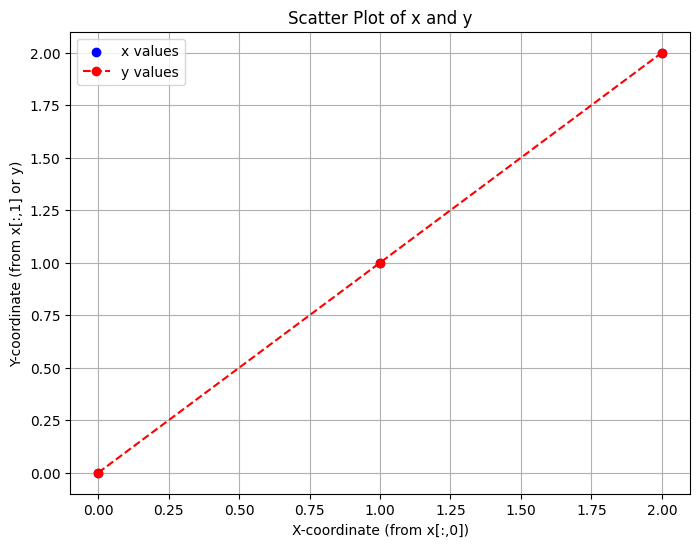

In [6]:
import matplotlib.pyplot as plt

# Assuming 'x_coords' and 'y' are already defined from previous cells
x_coords = x[:, 0]
y_coords = y # Define y_coords to match y for plotting

plt.figure(figsize=(8, 6))
plt.scatter(x_coords, y_coords, color='blue', label='x values')
plt.plot(x_coords, y, color='red', linestyle='--', marker='o', label='y values')

plt.title('Scatter Plot of x and y')
plt.xlabel('X-coordinate (from x[:,0])')
plt.ylabel('Y-coordinate (from x[:,1] or y)')
plt.grid(True)
plt.legend()
plt.show() # 이 부분이 그래프를 표시합니다.

In [7]:
# 5. Predicting (예측)
# 학습된 모델을 사용하여 새로운 데이터 [[3, 3]]에 대한 결과를 예측합니다.
reg = linear_model.LinearRegression() # Define 'reg' as a LinearRegression model
reg.fit(x, y) # Fit the model with your data 'x' and 'y'
prediction = reg.predict([[3, 3]])

print(f"입력 [[3, 3]]에 대한 예측 결과: {prediction}")

# 회귀 계수(Coefficients)와 절편(Intercept) 확인
print(f"회귀 계수 (Coefficients): {reg.coef_}")
print(f"절편 (Intercept): {reg.intercept_:.4f}")

입력 [[3, 3]]에 대한 예측 결과: [3.]
회귀 계수 (Coefficients): [0.5 0.5]
절편 (Intercept): 0.0000


In [8]:
from sklearn import linear_model
import numpy as np

# 1. Arrange Data (데이터 준비)
# 입력 특성 X와 타겟 값 y를 정의합니다.
X = [[0, 0], [1, 1], [2, 2]]
y = [0, 1, 2]

# 2. Choose Algorithm & 3. Class instantiation (모델 객체 생성)
# 선형 회귀 모델 알고리즘을 선택하고 객체를 생성합니다.
reg = linear_model.LinearRegression()

# 4. Learning from data (모델 학습)
# fit 메서드를 사용하여 데이터로부터 패턴을 학습합니다.
reg.fit(X, y)

print("모델 학습이 완료되었습니다.")

모델 학습이 완료되었습니다.


In [9]:
# 1. 데이터 준비 (Arrange Data)
# X는 2차원 리스트(행렬), y는 1차원 리스트(벡터) 형태입니다.
X = [[0, 0], [1, 1], [2, 2]]
y = [0, 1, 2]

# 2. 알고리즘 선택 (Choose Algorithm)
from sklearn import linear_model

# 3. 클래스 인스턴스화 (Class/API Instantiation)
# 모델 객체를 생성합니다.
reg = linear_model.LinearRegression()

# 4. 데이터 학습 (Learning from data)
# 모델이 X와 y의 상관관계를 찾아내도록 훈련시킵니다.
reg.fit(X, y)

# 5. 예측 (Predicting)
# 새로운 데이터 [[3, 3]]을 넣었을 때의 결과값을 예측합니다.
prediction = reg.predict([[3, 3]])

# 결과 출력
print(f"예측 결과값: {prediction}")

예측 결과값: [3.]
